<a href="https://colab.research.google.com/github/dhanushkumar2968/Car-colour-detection-Model/blob/main/car_color_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Car Colour Detection & People Counter
**What this does:**
- Detects cars and people in traffic images
- Blue cars → shown with **RED** rectangle
- Other cars → shown with **BLUE** rectangle
- Counts total cars and people
- Simple GUI to upload and preview images

---
### ✅ Step 1: Install required libraries

In [ ]:
# Install all required packages
!pip install ultralytics opencv-python-headless ipywidgets Pillow --quiet
print("✅ All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 59.6 MB/s eta 0:00:00
✅ All packages installed successfully!


---
### ✅ Step 2: Connect to Kaggle and Download Dataset

**How to get your Kaggle API key:**
1. Go to [https://www.kaggle.com](https://www.kaggle.com) → Your Profile → Settings
2. Scroll to **API** section → Click **Create New Token**
3. A file `kaggle.json` will download — upload it below

In [ ]:
import os
import json

# ✏️ PASTE YOUR DETAILS HERE
KAGGLE_USERNAME = "dhanush2968"   # ← change this
KAGGLE_KEY = "colab_new"             # ← change this (the long code)

# Save it automatically
os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_config = {"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle API key saved successfully!")

✅ Kaggle API key saved successfully!


In [ ]:
# Download a traffic/car dataset from Kaggle
# We are using a vehicle detection dataset — change the dataset name if you want another
!pip install kaggle --quiet

# Download the dataset (this is a publicly available car images dataset)
!kaggle datasets download -d saumyapatel/traffic-vehicles-object-detection --unzip -p /content/dataset/

print("✅ Dataset downloaded!")

# Show what files were downloaded
import os
for root, dirs, files_list in os.walk('/content/dataset/'):
    for file in files_list[:10]:  # Show first 10 files
        print(os.path.join(root, file))

Dataset URL: https://www.kaggle.com/datasets/saumyapatel/traffic-vehicles-object-detection
License(s): unknown
100% 607M/607M [00:04<00:00, 132MB/s]

✅ Dataset downloaded!
/content/dataset/Traffic Dataset/images/val/00 (209).jpg
/content/dataset/Traffic Dataset/images/val/Video10_28.jpg
/content/dataset/Traffic Dataset/images/val/00 (237).jpg
/content/dataset/Traffic Dataset/images/val/00 (130).jpg
/content/dataset/Traffic Dataset/images/val/00 (154).jpg
/content/dataset/Traffic Dataset/images/val/Video10_36.jpg
/content/dataset/Traffic Dataset/images/val/00 (56).jpg
/content/dataset/Traffic Dataset/images/val/Video10_39.jpg
/content/dataset/Traffic Dataset/images/val/00 (287).jpg
/content/dataset/Traffic Dataset/images/val/00 (812).jpg
/content/dataset/Traffic Dataset/images/train/Video6_10.jpg
/content/dataset/Traffic Dataset/images/train/00 (453).jpg
/content/dataset/Traffic Dataset/images/train/Video2_21.jpg
/content/dataset/Traffic Dataset/images/train/Video7_40.jpg
/content/datas

---
### ✅ Step 3: Load the YOLOv8 Model
We use YOLOv8 (pre-trained) — no training needed! It already knows how to detect cars and people.

In [ ]:
from ultralytics import YOLO

# Load pre-trained YOLOv8 model (downloads automatically, ~6MB)
model = YOLO('yolov8n.pt')
print("✅ YOLOv8 model loaded successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ YOLOv8 model loaded successfully!


---
### ✅ Step 4: Core Detection Functions

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────
# FUNCTION 1: Detect if a car region is BLUE
# ─────────────────────────────────────────────
def is_blue_car(image_bgr, box):
    """
    Checks if the car inside the bounding box is blue.
    Uses HSV color space — better for color detection than RGB.
    """
    x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])

    # Crop the car region from the image
    car_region = image_bgr[y1:y2, x1:x2]

    if car_region.size == 0:
        return False

    # Convert to HSV (Hue, Saturation, Value)
    hsv = cv2.cvtColor(car_region, cv2.COLOR_BGR2HSV)

    # Blue color range in HSV
    lower_blue = np.array([100, 50, 50])   # Dark blue
    upper_blue = np.array([140, 255, 255]) # Light blue

    # Create a mask — white where blue pixels are found
    mask = cv2.inRange(hsv, lower_blue, upper_blue)

    # Calculate percentage of blue pixels
    blue_percent = (np.sum(mask > 0) / mask.size) * 100

    # If more than 15% pixels are blue → it's a blue car
    return blue_percent > 15


# ─────────────────────────────────────────────
# FUNCTION 2: Main Detection Pipeline
# ─────────────────────────────────────────────
def detect_and_draw(image_path):
    """
    Main function:
    - Runs YOLO detection
    - Draws RED box for blue cars
    - Draws BLUE box for other cars
    - Counts people
    - Returns the annotated image
    """
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Could not load image: {image_path}")
        return None

    # Run YOLO detection
    results = model(image, verbose=False)

    car_count = 0
    blue_car_count = 0
    person_count = 0

    # YOLO class IDs: 0=person, 2=car, 3=motorcycle, 5=bus, 7=truck
    VEHICLE_CLASSES = {2: 'Car', 3: 'Motorcycle', 5: 'Bus', 7: 'Truck'}

    for result in results:
        for box in result.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            coords = box.xyxy[0].tolist()  # [x1, y1, x2, y2]

            # Only process detections with confidence > 40%
            if confidence < 0.4:
                continue

            x1, y1, x2, y2 = int(coords[0]), int(coords[1]), int(coords[2]), int(coords[3])

            # ── PERSON DETECTION ──
            if class_id == 0:
                person_count += 1
                # Green rectangle for people
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(image, f'Person {confidence:.0%}',
                            (x1, y1 - 8), cv2.FONT_HERSHEY_SIMPLEX,
                            0.5, (0, 255, 0), 2)

            # ── VEHICLE DETECTION ──
            elif class_id in VEHICLE_CLASSES:
                car_count += 1
                vehicle_name = VEHICLE_CLASSES[class_id]

                # Check if this vehicle is BLUE
                blue = is_blue_car(image, coords)

                if blue:
                    blue_car_count += 1
                    box_color = (0, 0, 255)   # RED rectangle for blue cars (BGR format)
                    label = f'BLUE {vehicle_name} {confidence:.0%}'
                else:
                    box_color = (255, 0, 0)   # BLUE rectangle for other cars (BGR format)
                    label = f'{vehicle_name} {confidence:.0%}'

                # Draw bounding box
                cv2.rectangle(image, (x1, y1), (x2, y2), box_color, 2)

                # Draw label background
                label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)[0]
                cv2.rectangle(image, (x1, y1 - 20), (x1 + label_size[0], y1), box_color, -1)
                cv2.putText(image, label, (x1, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    # ── SUMMARY BOX (top-left corner) ──
    summary_lines = [
        f'Total Vehicles : {car_count}',
        f'Blue Vehicles  : {blue_car_count}',
        f'People         : {person_count}'
    ]

    # Draw dark background for summary
    cv2.rectangle(image, (5, 5), (260, 80), (0, 0, 0), -1)
    cv2.rectangle(image, (5, 5), (260, 80), (255, 255, 255), 1)

    for i, line in enumerate(summary_lines):
        cv2.putText(image, line, (12, 25 + i * 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)

    # ── COLOR LEGEND (top-right corner) ──
    h, w = image.shape[:2]
    legend_x = w - 220
    cv2.rectangle(image, (legend_x, 5), (w - 5, 80), (0, 0, 0), -1)
    cv2.rectangle(image, (legend_x, 5), (w - 5, 80), (255, 255, 255), 1)
    cv2.putText(image, 'LEGEND', (legend_x + 60, 22),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    cv2.rectangle(image, (legend_x + 10, 30), (legend_x + 30, 45), (0, 0, 255), -1)
    cv2.putText(image, 'Blue Car', (legend_x + 38, 43),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)
    cv2.rectangle(image, (legend_x + 10, 52), (legend_x + 30, 67), (255, 0, 0), -1)
    cv2.putText(image, 'Other Car', (legend_x + 38, 65),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

    print(f"\n📊 Results:")
    print(f"   🚗 Total vehicles detected : {car_count}")
    print(f"   🔵 Blue vehicles           : {blue_car_count}")
    print(f"   👤 People detected         : {person_count}")

    return image

print("✅ Detection functions ready!")

✅ Detection functions ready!


---
### ✅ Step 5: Simple GUI — Upload & Detect

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from google.colab import files
import io

# ── Upload Button ──
upload_btn = widgets.Button(
    description='📁 Upload Image',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='40px')
)

# ── Output area ──
output_area = widgets.Output()

def on_upload_click(b):
    with output_area:
        clear_output(wait=True)
        print("📂 Select an image file (jpg/png)...")

        # Open file upload dialog
        uploaded = files.upload()

        for filename, content in uploaded.items():
            # Save uploaded file
            save_path = f'/content/{filename}'
            with open(save_path, 'wb') as f:
                f.write(content)

            print(f"\n🔍 Processing: {filename}")
            print("Please wait...")

            # Show original image
            original = Image.open(save_path)
            plt.figure(figsize=(14, 6))

            plt.subplot(1, 2, 1)
            plt.imshow(original)
            plt.title('📷 Original Image', fontsize=14, fontweight='bold')
            plt.axis('off')

            # Run detection
            result_image = detect_and_draw(save_path)

            if result_image is not None:
                # Convert BGR to RGB for matplotlib
                result_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

                plt.subplot(1, 2, 2)
                plt.imshow(result_rgb)
                plt.title('🎯 Detection Result', fontsize=14, fontweight='bold')
                plt.axis('off')

                plt.tight_layout()
                plt.savefig('/content/result.jpg', dpi=150, bbox_inches='tight')
                plt.show()

                print("\n✅ Done! Result saved as /content/result.jpg")
                print("📥 You can download it from the Files panel on the left.")

upload_btn.on_click(on_upload_click)

# ── Display GUI ──
print("═" * 50)
print("   🚗 CAR COLOUR DETECTION SYSTEM")
print("═" * 50)
print("  🔴 RED box   = Blue coloured car")
print("  🔵 BLUE box  = Other coloured car")
print("  🟢 GREEN box = Person")
print("═" * 50)
display(upload_btn, output_area)

══════════════════════════════════════════════════
   🚗 CAR COLOUR DETECTION SYSTEM
══════════════════════════════════════════════════
  🔴 RED box   = Blue coloured car
  🔵 BLUE box  = Other coloured car
  🟢 GREEN box = Person
══════════════════════════════════════════════════


Button(button_style='primary', description='📁 Upload Image', layout=Layout(height='40px', width='200px'), styl…

Output()

---
### ✅ Step 6: Test on Dataset Images (Batch Mode)
Run detection on the first 5 images from the downloaded dataset automatically.

📁 Found 1183 images in dataset

────────────────────────────────────────
Image 1: 00 (209).jpg

📊 Results:
   🚗 Total vehicles detected : 3
   🔵 Blue vehicles           : 1
   👤 People detected         : 4


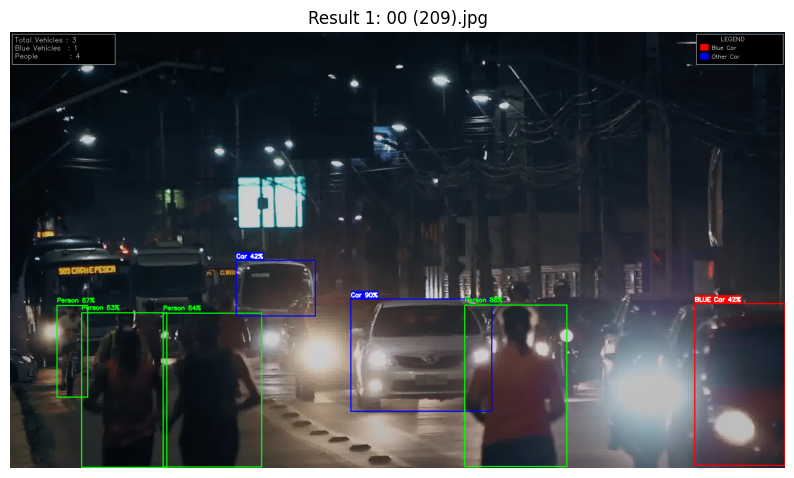


────────────────────────────────────────
Image 2: Video10_28.jpg

📊 Results:
   🚗 Total vehicles detected : 14
   🔵 Blue vehicles           : 9
   👤 People detected         : 5


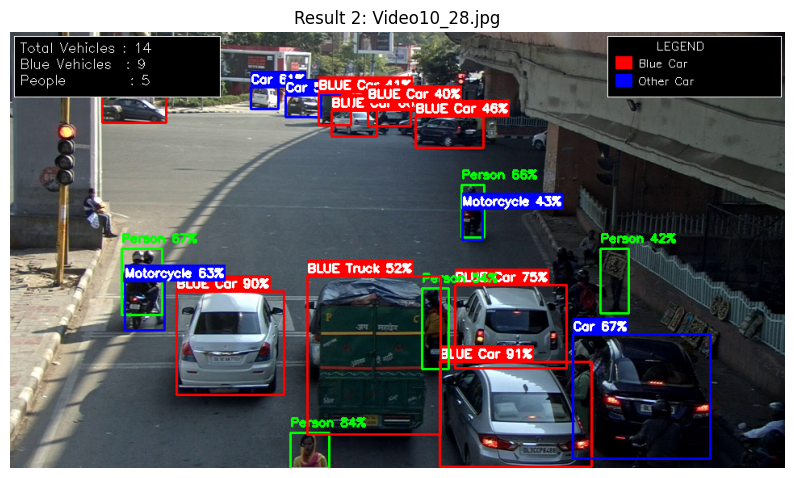


────────────────────────────────────────
Image 3: 00 (237).jpg

📊 Results:
   🚗 Total vehicles detected : 18
   🔵 Blue vehicles           : 18
   👤 People detected         : 0


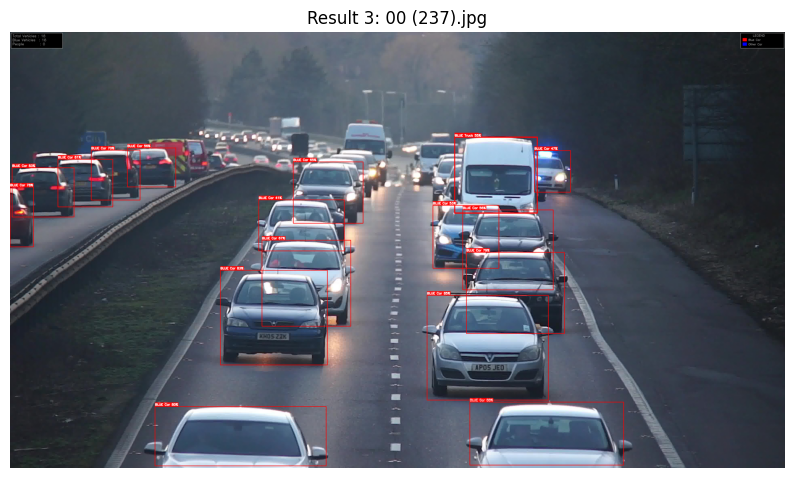


────────────────────────────────────────
Image 4: 00 (130).jpg

📊 Results:
   🚗 Total vehicles detected : 8
   🔵 Blue vehicles           : 5
   👤 People detected         : 1


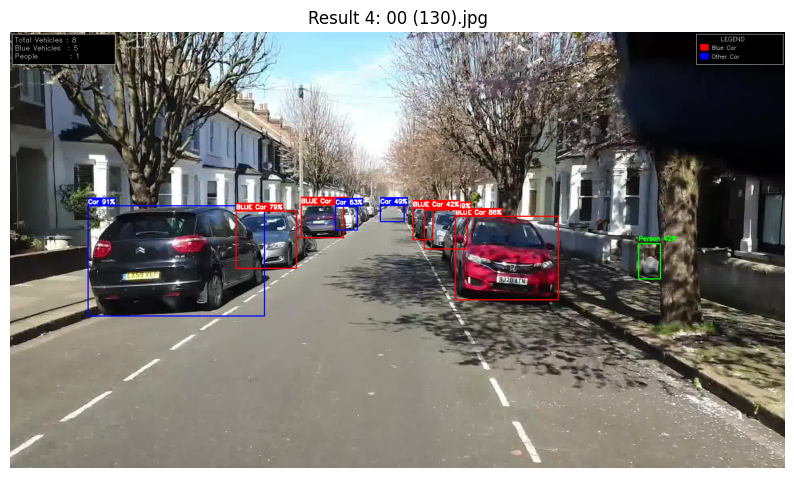


────────────────────────────────────────
Image 5: 00 (154).jpg

📊 Results:
   🚗 Total vehicles detected : 5
   🔵 Blue vehicles           : 0
   👤 People detected         : 3


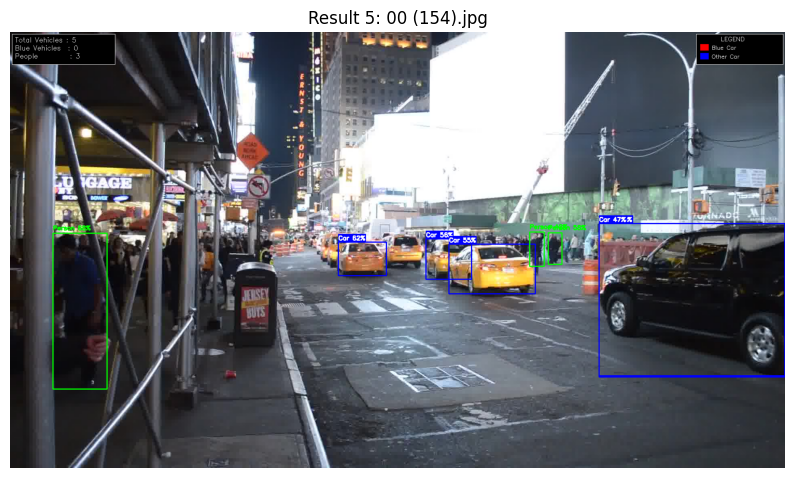


✅ Batch processing complete!


In [ ]:
import glob

# Find all image files in the dataset
image_files = glob.glob('/content/dataset/**/*.jpg', recursive=True) + \
              glob.glob('/content/dataset/**/*.png', recursive=True)

print(f"📁 Found {len(image_files)} images in dataset")

# Process first 5 images
for i, img_path in enumerate(image_files[:5]):
    print(f"\n{'─'*40}")
    print(f"Image {i+1}: {img_path.split('/')[-1]}")

    result = detect_and_draw(img_path)

    if result is not None:
        result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 6))
        plt.imshow(result_rgb)
        plt.title(f'Result {i+1}: {img_path.split("/")[-1]}', fontsize=12)
        plt.axis('off')
        plt.show()

print("\n✅ Batch processing complete!")